First, we need to install the `ultralytics` library, which provides the YOLOv6s model, and `opencv-python` for webcam access and video processing. We will install them using pip.

In [1]:
pip install ultralytics opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 18.0 MB/s eta 0:00:00


In [2]:
import os
import shutil
import random
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
!wget -O /content/hymenoptera_data.zip https://download.pytorch.org/tutorial/hymenoptera_data.zip

--2026-03-29 07:05:56--  https://download.pytorch.org/tutorial/hymenoptera_data.zip
Resolving download.pytorch.org (download.pytorch.org)... 3.170.73.38, 3.170.73.19, 3.170.73.34, ...
Connecting to download.pytorch.org (download.pytorch.org)|3.170.73.38|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 47286322 (45M) [application/zip]
Saving to: ‘/content/hymenoptera_data.zip’

/content/hymenopter 100%[===================>]  45.10M   211MB/s    in 0.2s    

2026-03-29 07:05:56 (211 MB/s) - ‘/content/hymenoptera_data.zip’ saved [47286322/47286322]



In [4]:
zip_path = "/content/hymenoptera_data.zip"
extract_path = "/content"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Done")
print("Dataset folder:", "/content/hymenoptera_data")

Done
Dataset folder: /content/hymenoptera_data


In [5]:
base_dir = Path("/content/hymenoptera_data")

for split in ["train", "val"]:
    print(f"\n{split.upper()}")
    for cls in os.listdir(base_dir / split):
        n = len(os.listdir(base_dir / split / cls))
        print(f"{cls}: {n}")


TRAIN
ants: 124
bees: 121

VAL
ants: 70
bees: 83


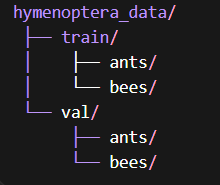

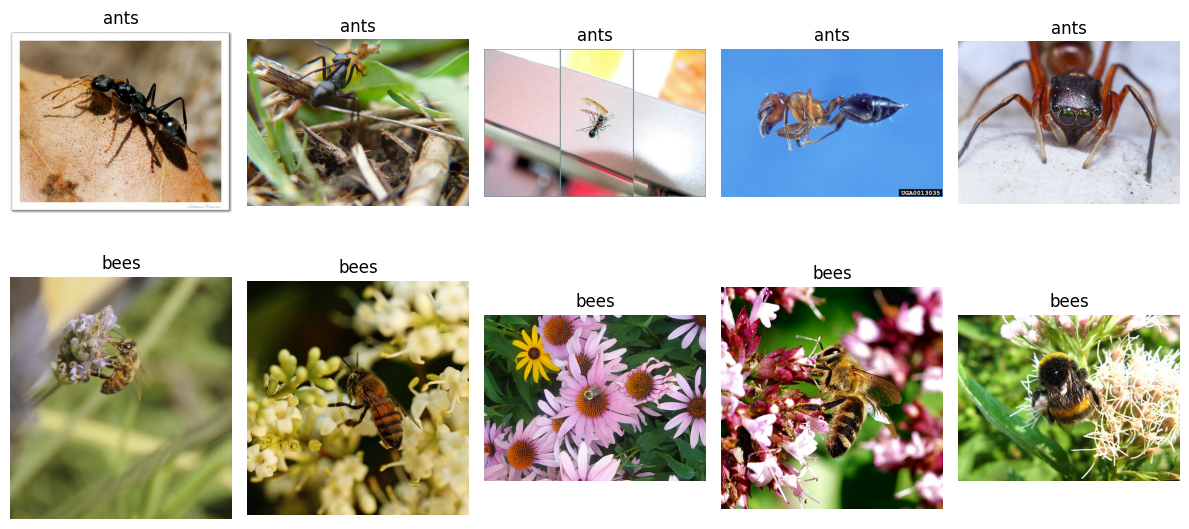

In [6]:
classes = ["ants", "bees"]

fig, axes = plt.subplots(2, 5, figsize=(12, 6))

for row, cls in enumerate(classes):
    folder = base_dir / "train" / cls
    imgs = random.sample(os.listdir(folder), 5)

    for col, img_name in enumerate(imgs):
        img = Image.open(folder / img_name)
        axes[row, col].imshow(img)
        axes[row, col].set_title(cls)
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

In [7]:
model = YOLO("yolo11n-cls.pt")

results = model.train(
    data="/content/hymenoptera_data",
    epochs=5,
    imgsz=224,
    batch=16
)

Ultralytics 8.4.31 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/hymenoptera_data, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=

In [ ]:
from ultralytics import YOLO

best_model_path = "/content/runs/classify/train/weights/best.pt"

best_model = YOLO(best_model_path)

In [ ]:
metrics = best_model.val(
    data="/content/hymenoptera_data",
    plots=True
)

Ultralytics 8.4.31 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n-cls summary (fused): 47 layers, 1,528,586 parameters, 0 gradients, 3.2 GFLOPs
train: /content/hymenoptera_data/train... found 244 images in 2 classes ✅ 
val: /content/hymenoptera_data/val... found 153 images in 2 classes ✅ 
test: None...
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1335.7±582.2 MB/s, size: 118.3 KB)
val: Scanning /content/hymenoptera_data/val... 153 images, 0 corrupt: 100% ━━━━━━━━━━━━ 153/153 64.2Mit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 10/10 9.0it/s 1.1s
                   all      0.902          1
Speed: 0.1ms preprocess, 2.4ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/runs/classify/val


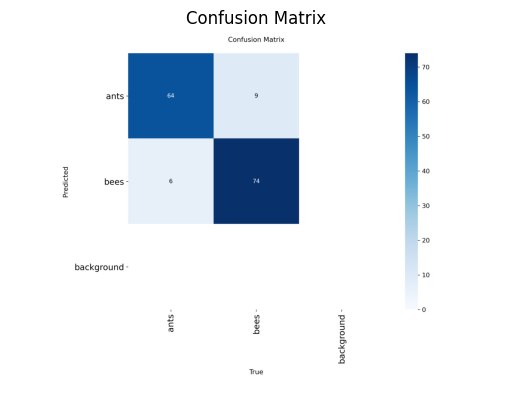

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

cm_path = "/content/runs/classify/val/confusion_matrix.png"

img = Image.open(cm_path)

plt.imshow(img)
plt.axis("off")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
from ultralytics import YOLO

model = YOLO("yolo11n-cls.pt")

model.train(
    data="/content/hymenoptera_data",
    epochs=10,
    imgsz=224,
    batch=16
)

Ultralytics 8.4.31 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/hymenoptera_data, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspectiv

ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79a9221542f0>
curves: []
curves_results: []
fitness: 0.9575163424015045
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.915032684803009, 'metrics/accuracy_top5': 1.0, 'fitness': 0.9575163424015045}
save_dir: PosixPath('/content/runs/classify/train2')
speed: {'preprocess': 0.15096032679781166, 'inference': 1.1747334182996532, 'loss': 0.039399810459168426, 'postprocess': 0.0004873202616342015}
top1: 0.915032684803009
top5: 1.0

Ultralytics 8.4.31 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n-cls summary (fused): 47 layers, 1,528,586 parameters, 0 gradients, 3.2 GFLOPs
train: /content/hymenoptera_data/train... found 244 images in 2 classes ✅ 
val: /content/hymenoptera_data/val... found 153 images in 2 classes ✅ 
test: None...
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1832.4±627.5 MB/s, size: 118.3 KB)
val: Scanning /content/hymenoptera_data/val... 153 images, 0 corrupt: 100% ━━━━━━━━━━━━ 153/153 35.7Mit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 10/10 8.9it/s 1.1s
                   all      0.915          1
Speed: 0.3ms preprocess, 1.3ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/runs/classify/val_10epochs


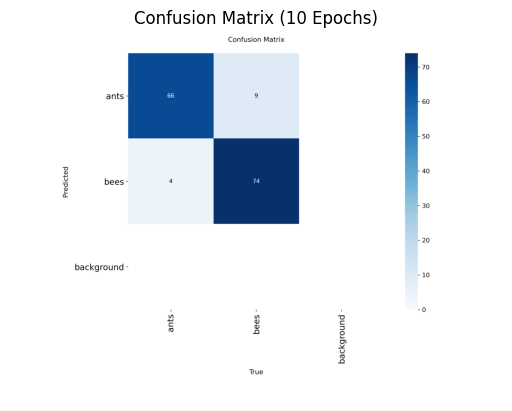

In [ ]:
from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt
import os

# --- Load SECOND model (train2) ---
model = YOLO("/content/runs/classify/train2/weights/best.pt")

# --- Run validation and save with a clear name ---
model.val(
    data="/content/hymenoptera_data",
    plots=True,
    name="val_10epochs"
)

# --- Path to confusion matrix ---
cm_path = "/content/runs/classify/val_10epochs/confusion_matrix.png"

# --- Display it ---
img = Image.open(cm_path)

plt.imshow(img)
plt.axis("off")
plt.title("Confusion Matrix (10 Epochs)")
plt.show()